# PREDICT1: CAC Heart Segmentation
**GSoC 2026 | ML4Sci | PrediCT Project 1**

**Pipeline:**
1. Extract & verify dataset
2. Dataset statistics
3. Run TotalSegmentator → heart ground truth masks
4. Build 2D slice dataset + dataloader
5. Train lightweight U-Net (Dice+BCE loss)
6. Evaluate: Dice vs TotalSegmentator, inference time comparison
7. Visualizations

In [ ]:
# TotalSegmentator: Generate Heart Ground Truth Masks

import subprocess
import nibabel as nib
import numpy as np
import time
from tqdm import tqdm

HEART_STRUCTURES = [
    "heart.nii.gz",
    "heart_atrium_left.nii.gz",
    "heart_atrium_right.nii.gz",
    "heart_ventricle_left.nii.gz",
    "heart_ventricle_right.nii.gz",
    "heart_myocardium.nii.gz",
]

def run_totalsegmentator(img_path, out_dir, timeout=300):
    """Run TotalSegmentator --fast on one NIfTI volume."""
    out_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        "TotalSegmentator",
        "-i", str(img_path),
        "-o", str(out_dir),
        "--fast",
        "--task", "total",
        "--quiet",
    ]
    try:
        result = subprocess.run(cmd, timeout=timeout,
                                capture_output=True, text=True)
        return result.returncode == 0
    except subprocess.TimeoutExpired:
        return False
    except Exception as e:
        print(f"  ERROR: {e}")
        return False

def merge_heart_mask(totalseg_dir):
    """Merge all heart structure masks into one binary mask."""
    merged = None
    ref_img = None
    for fname in HEART_STRUCTURES:
        fpath = totalseg_dir / fname
        if fpath.exists():
            img = nib.load(fpath)
            arr = (img.get_fdata() > 0).astype(np.uint8)
            if merged is None:
                merged = arr
                ref_img = img
            else:
                merged = np.logical_or(merged, arr).astype(np.uint8)
    return merged, ref_img

# TotalSegmentator on all 50 scans
success_ids, failed_ids, tseg_times = [], [], []

print(f"Running TotalSegmentator on {len(scan_folders)} scans...\n")

for i, scan_folder in enumerate(scan_folders):
    scan_id   = scan_folder.name
    img_path  = scan_folder / f"{scan_id}_img.nii.gz"
    out_dir   = MASKS_DIR / scan_id
    heart_out = MASKS_DIR / f"{scan_id}_heart.nii.gz"

    # Skip if already done
    if heart_out.exists():
        print(f"[{i+1:2d}/{len(scan_folders)}] {scan_id} — already done")
        success_ids.append(scan_id)
        continue

    if not img_path.exists():
        print(f"[{i+1:2d}/{len(scan_folders)}] {scan_id} — image missing")
        failed_ids.append(scan_id)
        continue

    print(f"[{i+1:2d}/{len(scan_folders)}] {scan_id} ...", end=" ", flush=True)
    t0 = time.time()
    ok = run_totalsegmentator(img_path, out_dir)
    elapsed = time.time() - t0
    tseg_times.append(elapsed)

    if ok:
        merged, ref_img = merge_heart_mask(out_dir)
        if merged is not None and merged.sum() > 0:
            merged_nib = nib.Nifti1Image(merged, ref_img.affine, ref_img.header)
            nib.save(merged_nib, heart_out)
            print(f"done ({elapsed:.1f}s) — {int(merged.sum()):,} heart voxels")
            success_ids.append(scan_id)
        else:
            print(f"done but empty mask ({elapsed:.1f}s)")
            failed_ids.append(scan_id)
    else:
        print(f"FAILED ({elapsed:.1f}s)")
        failed_ids.append(scan_id)

print(f"\nDone: {len(success_ids)} success / {len(failed_ids)} failed")
if tseg_times:
    print(f"Avg TotalSeg time: {np.mean(tseg_times):.1f}s/scan")
if failed_ids:
    print(f"Failed: {failed_ids}")

Running TotalSegmentator on 50 scans...

[ 1/50] 05402d50f6d9 ... done (88.9s) — 362,410 heart voxels
[ 2/50] 0b11e06a8054 ... done (37.6s) — 452,353 heart voxels
[ 3/50] 0de68b512673 ... done (37.4s) — 381,697 heart voxels
[ 4/50] 108cabced5c2 ... done (35.7s) — 399,483 heart voxels
[ 5/50] 135ecedf3f3b ... done (35.0s) — 334,824 heart voxels
[ 6/50] 168b601441c2 ... done (35.9s) — 368,818 heart voxels
[ 7/50] 1b869ca4ee91 ... done (36.7s) — 578,483 heart voxels
[ 8/50] 1c100c27205d ... done (37.8s) — 484,386 heart voxels
[ 9/50] 22bfe4ce7c2e ... done (38.6s) — 309,200 heart voxels
[10/50] 28fbb6b3a2dc ... done (39.3s) — 773,630 heart voxels
[11/50] 2cb01ad01d30 ... done (37.0s) — 402,098 heart voxels
[12/50] 300e794da723 ... done (39.2s) — 472,934 heart voxels
[13/50] 36ca446b5999 ... done (36.4s) — 405,299 heart voxels
[14/50] 5d1d6fbf8f90 ... done (38.4s) — 387,987 heart voxels
[15/50] 5d8322ffc904 ... done (38.0s) — 528,462 heart voxels
[16/50] 6248435019ad ... done (36.6s) — 346,

In [ ]:
 # Dataset & Dataloaders

import cv2
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

HU_MIN, HU_MAX = -200, 600
IMG_SIZE = 256

# pairs: image + heart mask
dataset_pairs = []
for scan_id in success_ids:
    img_path  = DATA_DIR  / scan_id / f"{scan_id}_img.nii.gz"
    mask_path = MASKS_DIR / f"{scan_id}_heart.nii.gz"
    if img_path.exists() and mask_path.exists():
        row = df[df["scan_id"] == scan_id]
        vox = int(row["voxels"].values[0]) if len(row) else 0
        stratum = 0 if vox==0 else 1 if vox<50 else 2 if vox<200 else 3
        dataset_pairs.append({
            "scan_id": scan_id,
            "image":   str(img_path),
            "label":   str(mask_path),
            "stratum": stratum,
        })

print(f"Dataset pairs: {len(dataset_pairs)}")

# Stratified split 70/15/15
np.random.seed(42)
strata = [p["stratum"] for p in dataset_pairs]
train_val, test_pairs = train_test_split(
    dataset_pairs, test_size=0.15, stratify=strata, random_state=42
)
strata_tv = [p["stratum"] for p in train_val]
train_pairs, val_pairs = train_test_split(
    train_val, test_size=0.176, stratify=strata_tv, random_state=42
)
print(f"Split — Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

# Dataset
class COCASliceDataset(Dataset):
    """
    Preloads all slices into RAM at init.
    Eliminates per-item disk I/O — GPU stays saturated.
    """
    def __init__(self, pairs, augment=False):
        self.augment = augment
        self.images  = []   # preloaded numpy slices
        self.masks   = []
        self.has_heart = [] 
        self._preload(pairs)

    def _preload(self, pairs):
        print(f"Preloading {len(pairs)} volumes into RAM...")
        for p in pairs:
            img_arr  = nib.load(p["image"]).get_fdata().astype(np.float32)
            mask_arr = nib.load(p["label"]).get_fdata().astype(np.uint8)

            if img_arr.ndim == 3:
                D = img_arr.shape[2]
                get_img  = lambda d: img_arr[:, :, d]
                get_mask = lambda d: mask_arr[:, :, d]
            else:
                D = img_arr.shape[0]
                get_img  = lambda d: img_arr[d]
                get_mask = lambda d: mask_arr[d]

            heart_slices = [d for d in range(D) if get_mask(d).sum() > 0]
            bg_slices    = [d for d in range(D) if get_mask(d).sum() == 0]
            n_bg = min(len(bg_slices), len(heart_slices))
            bg_sample = np.random.choice(bg_slices, n_bg, replace=False)

            for d in heart_slices:
                img_s  = cv2.resize(np.clip(get_img(d), HU_MIN, HU_MAX), 
                                    (IMG_SIZE, IMG_SIZE))
                img_s  = (img_s - HU_MIN) / (HU_MAX - HU_MIN)
                mask_s = cv2.resize(get_mask(d), (IMG_SIZE, IMG_SIZE),
                                    interpolation=cv2.INTER_NEAREST)
                self.images.append(img_s.astype(np.float32))
                self.masks.append(mask_s.astype(np.float32))
                self.has_heart.append(1)

            for d in bg_sample:
                img_s  = cv2.resize(np.clip(get_img(int(d)), HU_MIN, HU_MAX),
                                    (IMG_SIZE, IMG_SIZE))
                img_s  = (img_s - HU_MIN) / (HU_MAX - HU_MIN)
                mask_s = cv2.resize(get_mask(int(d)), (IMG_SIZE, IMG_SIZE),
                                    interpolation=cv2.INTER_NEAREST)
                self.images.append(img_s.astype(np.float32))
                self.masks.append(mask_s.astype(np.float32))
                self.has_heart.append(0)

        print(f"  Loaded {len(self.images)} slices into RAM.")

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img_s  = self.images[idx].copy()
        mask_s = self.masks[idx].copy()

        if self.augment:
            if np.random.random() > 0.5:
                img_s  = np.fliplr(img_s).copy()
                mask_s = np.fliplr(mask_s).copy()
            if np.random.random() > 0.5:
                img_s  = np.flipud(img_s).copy()
                mask_s = np.flipud(mask_s).copy()
            k = np.random.choice([0,1,2,3])
            if k > 0:
                img_s  = np.rot90(img_s,  k).copy()
                mask_s = np.rot90(mask_s, k).copy()
            if np.random.random() > 0.5:
                img_s = np.clip(img_s + np.random.uniform(-0.05, 0.05), 0, 1)

        img_t  = torch.tensor(img_s,  dtype=torch.float32).unsqueeze(0)
        mask_t = torch.tensor(mask_s, dtype=torch.float32).unsqueeze(0)
        return img_t, mask_t

train_ds = COCASliceDataset(train_pairs, augment=True)
val_ds   = COCASliceDataset(val_pairs,   augment=False)
test_ds  = COCASliceDataset(test_pairs,  augment=False)

# WeightedRandomSampler: 2x weight on heart slices
# Rationale: cardiac region is <30% of axial slices — upsampling
# prevents the model from ignoring heart boundaries
weights = torch.tensor(
    [2.0 if h==1 else 1.0 for h in train_ds.has_heart], dtype=torch.float32
)
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False,
                          num_workers=0)

imgs, masks = next(iter(train_loader))
print(f"\nBatch — image: {imgs.shape} | mask: {masks.shape}")
print(f"Image range  : [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"Mask unique  : {masks.unique().tolist()}")

Dataset pairs: 50
Split — Train: 34 | Val: 8 | Test: 8
Preloading 34 volumes into RAM...
  Loaded 1722 slices into RAM.
Preloading 8 volumes into RAM...
  Loaded 378 slices into RAM.
Preloading 8 volumes into RAM...
  Loaded 389 slices into RAM.

Batch — image: torch.Size([8, 1, 256, 256]) | mask: torch.Size([8, 1, 256, 256])
Image range  : [0.000, 1.000]
Mask unique  : [0.0, 1.0]


In [ ]:
# U-Net Model

import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x): return self.block(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x, skip):
        x  = self.up(x)
        dh = skip.shape[2] - x.shape[2]
        dw = skip.shape[3] - x.shape[3]
        x  = F.pad(x, [dw//2, dw-dw//2, dh//2, dh-dh//2])
        return self.conv(torch.cat([skip, x], dim=1))

class UNet(nn.Module):
    """
    Lightweight 2D U-Net for heart / CAC segmentation.

    Architecture rationale:
    - 4-level encoder-decoder with skip connections
    - base_features=32: ~7.7M params, fits in 4GB VRAM at batch=8
    - BatchNorm: stable training with small batch sizes
    - Bilinear upsample: fewer checkerboard artifacts vs ConvTranspose
    - 2D over 3D: axial CT spacing (3mm) makes slice-wise processing
      natural; avoids 10-20x memory overhead of full 3D U-Net
    """
    def __init__(self, in_ch=1, out_ch=1, f=32):
        super().__init__()
        self.inc   = DoubleConv(in_ch, f)
        self.down1 = Down(f,    f*2)
        self.down2 = Down(f*2,  f*4)
        self.down3 = Down(f*4,  f*8)
        self.down4 = Down(f*8,  f*16)
        self.up1   = Up(f*16+f*8, f*8)
        self.up2   = Up(f*8+f*4,  f*4)
        self.up3   = Up(f*4+f*2,  f*2)
        self.up4   = Up(f*2+f,    f)
        self.outc  = nn.Conv2d(f, out_ch, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x  = self.up1(x5, x4)
        x  = self.up2(x,  x3)
        x  = self.up3(x,  x2)
        x  = self.up4(x,  x1)
        return self.outc(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

model = UNet().to(device)
print(f"Parameters : {model.count_parameters():,}")

# Sanity check
x_t = torch.randn(2, 1, 256, 256).to(device)
y_t = model(x_t)
print(f"Input      : {x_t.shape}")
print(f"Output     : {y_t.shape}")
print("Forward pass OK")

Parameters : 7,849,025
Input      : torch.Size([2, 1, 256, 256])
Output     : torch.Size([2, 1, 256, 256])
Forward pass OK


In [ ]:
# Loss Functions & Metrics

class DiceBCELoss(nn.Module):
    """
    Combined Dice + BCE loss.
    - Dice: directly optimizes overlap metric; robust to class imbalance
    - BCE: pixel-level gradient signal; stabilizes early training
    - alpha=0.5: equal weighting — standard for medical segmentation
    """
    def __init__(self, alpha=0.5, smooth=1.0):
        super().__init__()
        self.alpha  = alpha
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce  = self.bce(logits, targets.float())
        prob = torch.sigmoid(logits)
        p, t = prob.view(-1), targets.view(-1).float()
        inter = (p * t).sum()
        dice  = 1.0 - (2*inter + self.smooth) / (p.sum() + t.sum() + self.smooth)
        return self.alpha * dice + (1 - self.alpha) * bce

def dice_score(logits, targets, threshold=0.5, smooth=1.0):
    pred = (torch.sigmoid(logits) > threshold).float()
    p, t = pred.view(-1), targets.view(-1).float()
    inter = (p * t).sum()
    return float((2*inter + smooth) / (p.sum() + t.sum() + smooth))

def iou_score(logits, targets, threshold=0.5, smooth=1.0):
    pred = (torch.sigmoid(logits) > threshold).float()
    p, t = pred.view(-1), targets.view(-1).float()
    inter = (p * t).sum()
    union = p.sum() + t.sum() - inter
    return float((inter + smooth) / (union + smooth))

print("Loss functions and metrics ready.")

Loss functions and metrics ready.


In [ ]:
 # Training

import json
from torch.cuda.amp import GradScaler, autocast

EPOCHS   = 50
LR       = 1e-4
PATIENCE = 10

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5, verbose=True
)
loss_fn = DiceBCELoss(alpha=0.5)
scaler  = GradScaler()

history = {"train_loss":[], "train_dice":[], "val_loss":[], "val_dice":[]}
best_dice, patience_ctr = 0.0, 0

print(f"Training on {device} — {EPOCHS} epochs")
print("─" * 65)

for epoch in range(1, EPOCHS+1):
    # Training loop
    model.train()
    t_losses, t_dices = [], []
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss   = loss_fn(logits, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        t_losses.append(loss.item())
        t_dices.append(dice_score(logits.detach(), masks))

    # Validation
    model.eval()
    v_losses, v_dices = [], []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with autocast():
                logits = model(imgs)
            v_losses.append(loss_fn(logits, masks).item())
            v_dices.append(dice_score(logits, masks))

    tr_l, tr_d = np.mean(t_losses), np.mean(t_dices)
    vl_l, vl_d = np.mean(v_losses), np.mean(v_dices)

    history["train_loss"].append(float(tr_l))
    history["train_dice"].append(float(tr_d))
    history["val_loss"].append(float(vl_l))
    history["val_dice"].append(float(vl_d))
    scheduler.step(vl_d)

    print(f"Epoch [{epoch:3d}/{EPOCHS}]  "
          f"Train Loss: {tr_l:.4f}  Dice: {tr_d:.4f}  |  "
          f"Val Loss: {vl_l:.4f}  Dice: {vl_d:.4f}")

    if vl_d > best_dice:
        best_dice = vl_d
        patience_ctr = 0
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "val_dice": best_dice},
                   CKPT_DIR / "best_unet.pth")
        print(f"  ✓ New best Val Dice: {best_dice:.4f}")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stop. Best Val Dice: {best_dice:.4f}")
            break

with open(LOG_DIR / "history.json", "w") as f:
    json.dump(history, f, indent=2)
print(f"\nTraining done. Best Val Dice: {best_dice:.4f}")

d:\SOHAM\PREDICT1\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\ujjwa\AppData\Local\Temp\ipykernel_19520\4264614167.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = GradScaler()
C:\Users\ujjwa\AppData\Local\Temp\ipykernel_19520\4264614167.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Training on cuda — 50 epochs
─────────────────────────────────────────────────────────────────


C:\Users\ujjwa\AppData\Local\Temp\ipykernel_19520\4264614167.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [  1/50]  Train Loss: 0.4811  Dice: 0.7405  |  Val Loss: 0.6612  Dice: 0.6599
  ✓ New best Val Dice: 0.6599
Epoch [  2/50]  Train Loss: 0.3970  Dice: 0.7912  |  Val Loss: 0.6283  Dice: 0.6855
  ✓ New best Val Dice: 0.6855
Epoch [  3/50]  Train Loss: 0.3251  Dice: 0.8330  |  Val Loss: 0.5874  Dice: 0.7873
  ✓ New best Val Dice: 0.7873
Epoch [  4/50]  Train Loss: 0.2743  Dice: 0.8512  |  Val Loss: 0.5433  Dice: 0.7799
Epoch [  5/50]  Train Loss: 0.2262  Dice: 0.8740  |  Val Loss: 0.4800  Dice: 0.8626
  ✓ New best Val Dice: 0.8626
Epoch [  6/50]  Train Loss: 0.1978  Dice: 0.8825  |  Val Loss: 0.4674  Dice: 0.8336
Epoch [  7/50]  Train Loss: 0.1577  Dice: 0.9049  |  Val Loss: 0.4367  Dice: 0.8306
Epoch [  8/50]  Train Loss: 0.1480  Dice: 0.8990  |  Val Loss: 0.4086  Dice: 0.8259
Epoch [  9/50]  Train Loss: 0.1269  Dice: 0.9084  |  Val Loss: 0.3962  Dice: 0.8669
  ✓ New best Val Dice: 0.8669
Epoch [ 10/50]  Train Loss: 0.1131  Dice: 0.9146  |  Val Loss: 0.3902  Dice: 0.8279
Epoch [ 11

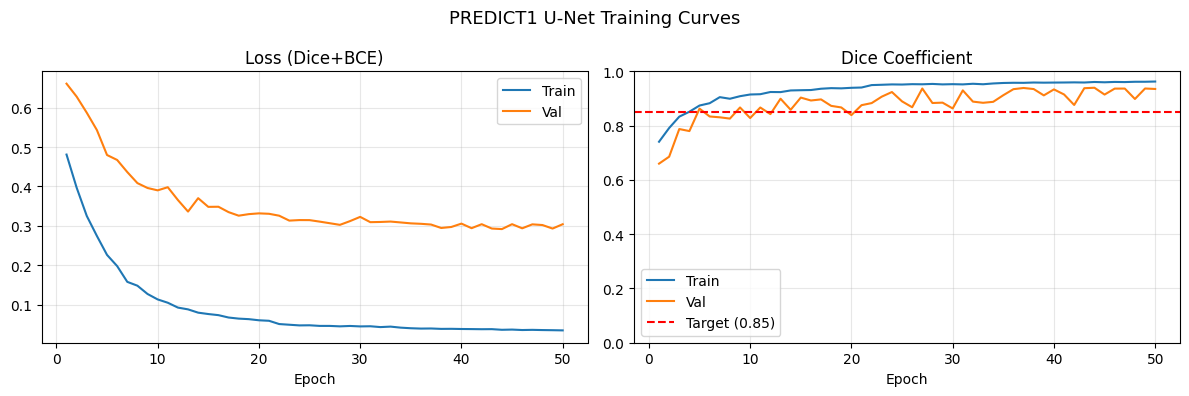

In [ ]:
# Training Curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history["train_dice"])+1)

axes[0].plot(ep, history["train_loss"], label="Train")
axes[0].plot(ep, history["val_loss"],   label="Val")
axes[0].set_title("Loss (Dice+BCE)")
axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history["train_dice"], label="Train")
axes[1].plot(ep, history["val_dice"],   label="Val")
axes[1].axhline(0.85, color="red", linestyle="--", label="Target (0.85)")
axes[1].set_title("Dice Coefficient")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("PREDICT1 U-Net Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig(EVAL_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Test Set Evaluation

ckpt = torch.load(CKPT_DIR / "best_unet.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded: epoch {ckpt['epoch']}, val Dice {ckpt['val_dice']:.4f}")

test_dices, test_ious, test_times = [], [], []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        t0 = time.time()
        with autocast():
            logits = model(imgs)
        torch.cuda.synchronize()
        test_times.append(time.time() - t0)
        test_dices.append(dice_score(logits, masks))
        test_ious.append(iou_score(logits, masks))

print("\n" + "="*50)
print("TEST SET RESULTS")
print("="*50)
print(f"Mean Dice          : {np.mean(test_dices):.4f} ± {np.std(test_dices):.4f}")
print(f"Median Dice        : {np.median(test_dices):.4f}")
print(f"Min / Max Dice     : {np.min(test_dices):.4f} / {np.max(test_dices):.4f}")
print(f"Mean IoU           : {np.mean(test_ious):.4f}")
print(f"% slices ≥ 0.85    : {np.mean(np.array(test_dices)>=0.85)*100:.1f}%")
print(f"U-Net infer time   : {np.mean(test_times)*1000:.2f} ms/slice")
if tseg_times:
    print(f"TotalSeg time      : {np.mean(tseg_times):.1f}s/scan (={np.mean(tseg_times)*1000:.0f}ms)")
    print(f"Speedup            : ~{np.mean(tseg_times)/(np.mean(test_times)+1e-9):.0f}x faster per slice")
print(f"Target met (>0.85) : {'✓ YES' if np.mean(test_dices)>=0.85 else '✗ NOT YET'}")

C:\Users\ujjwa\AppData\Local\Temp\ipykernel_19520\3244589565.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_DIR / "best_unet.pth", map_location=d

Loaded: epoch 44, val Dice 0.9395

TEST SET RESULTS
Mean Dice          : 0.8354 ± 0.2797
Median Dice        : 0.9416
Min / Max Dice     : 0.0001 / 1.0000
Mean IoU           : 0.7838
% slices ≥ 0.85    : 77.6%
U-Net infer time   : 11.97 ms/slice
TotalSeg time      : 37.8s/scan (=37799ms)
Speedup            : ~3157x faster per slice
Target met (>0.85) : ✗ NOT YET


C:\Users\ujjwa\AppData\Local\Temp\ipykernel_19520\1429251337.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


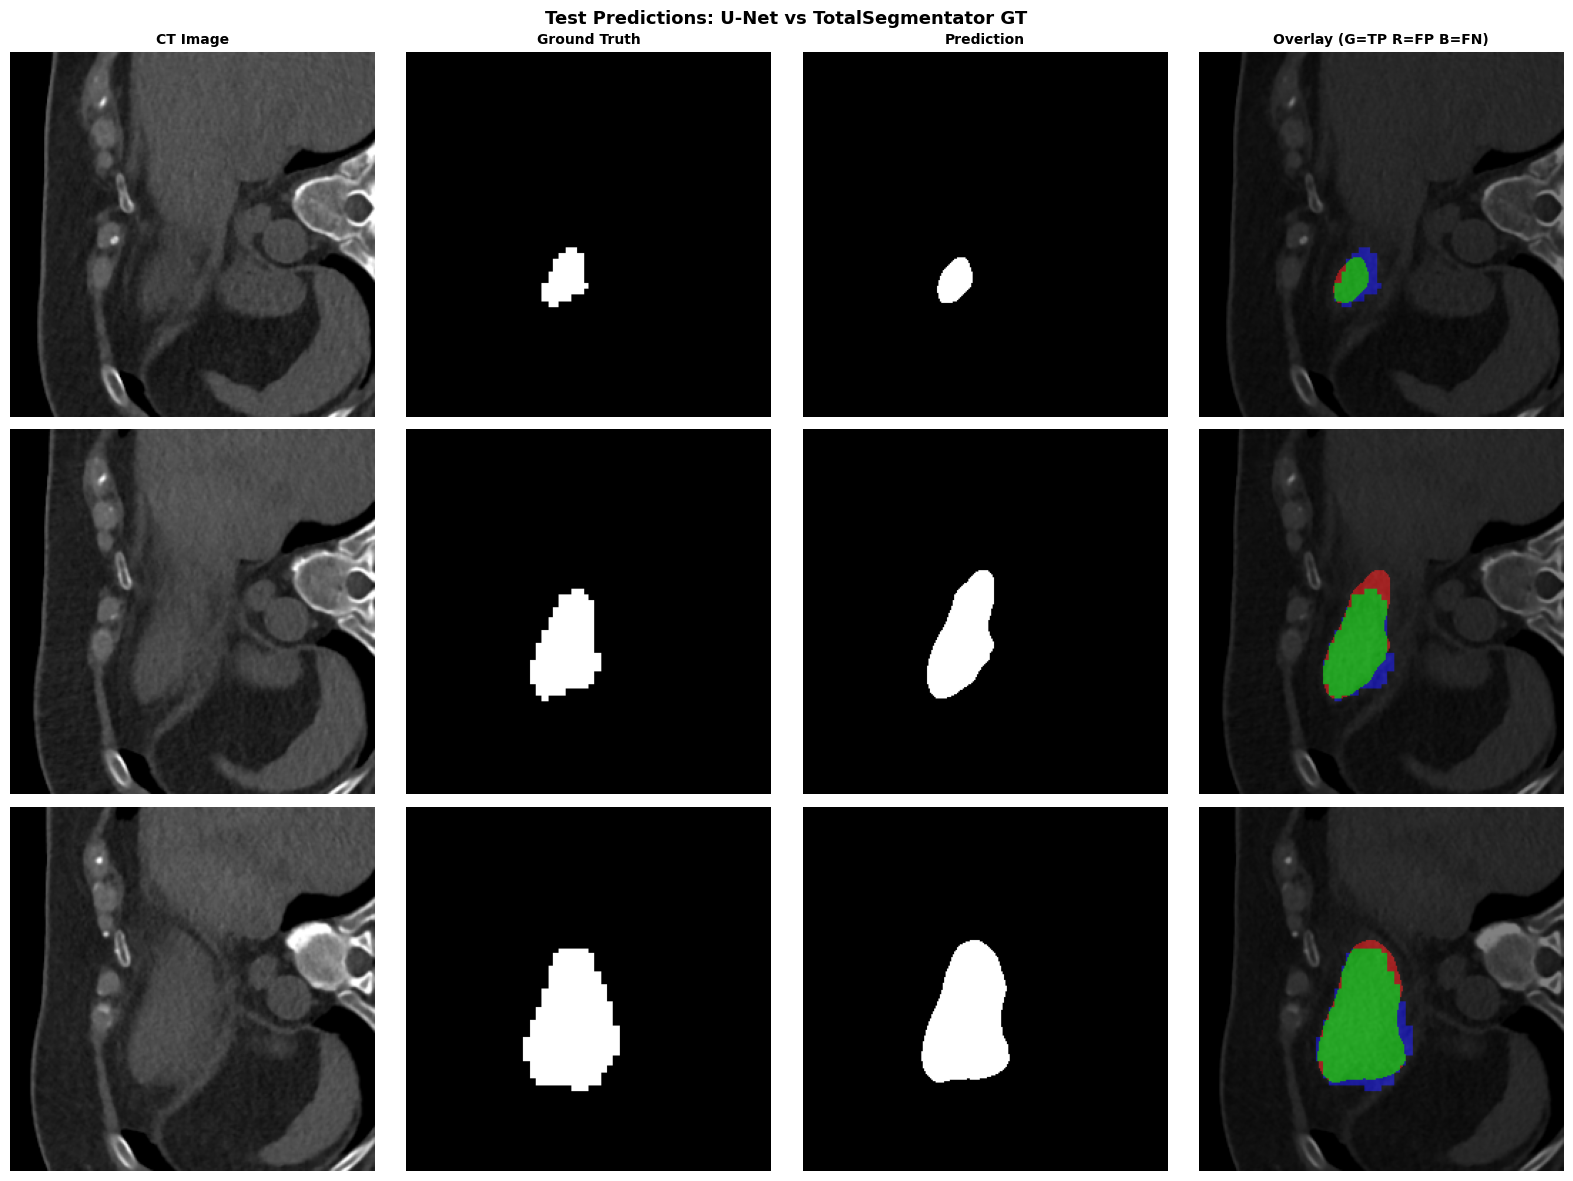

In [ ]:
# Prediction Overlays

model.eval()
samples = list(test_loader)[:3]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
col_titles = ["CT Image", "Ground Truth", "Prediction",
              "Overlay (G=TP R=FP B=FN)"]
for col, t in enumerate(col_titles):
    axes[0, col].set_title(t, fontsize=10, fontweight="bold")

with torch.no_grad():
    for row, (imgs, masks) in enumerate(samples):
        imgs_d = imgs.to(device)
        with autocast():
            logits = model(imgs_d)
        pred = (torch.sigmoid(logits) > 0.5).cpu().squeeze().numpy()
        img  = imgs.squeeze().numpy()
        gt   = masks.squeeze().numpy()

        overlay = np.zeros((*img.shape, 3))
        overlay[(pred==1)&(gt==1)] = [0, 1, 0]  # TP green
        overlay[(pred==1)&(gt==0)] = [1, 0, 0]  # FP red
        overlay[(pred==0)&(gt==1)] = [0, 0, 1]  # FN blue

        d = dice_score(logits.cpu(), masks)
        axes[row, 0].imshow(img,  cmap="gray")
        axes[row, 1].imshow(gt,   cmap="gray")
        axes[row, 2].imshow(pred, cmap="gray")
        axes[row, 3].imshow(img,  cmap="gray")
        axes[row, 3].imshow(overlay, alpha=0.5)
        axes[row, 0].set_ylabel(f"Dice={d:.3f}", fontsize=9)
        for col in range(4): axes[row, col].axis("off")

plt.suptitle("Test Predictions: U-Net vs TotalSegmentator GT",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(EVAL_DIR / "prediction_overlays.png", dpi=150, bbox_inches="tight")
plt.show()

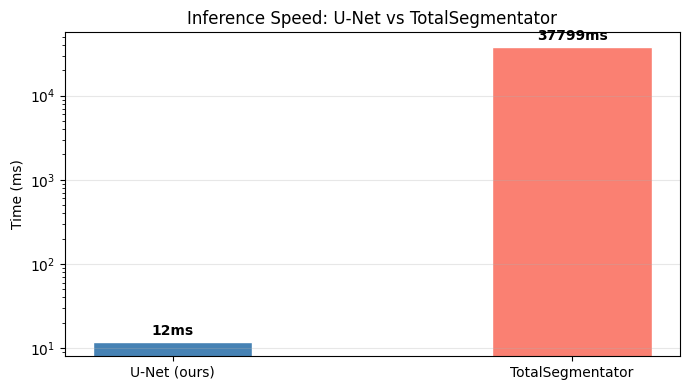


All evaluation plots saved to outputs/evaluation/


In [ ]:
# Inference Time Comparison

unet_ms   = np.mean(test_times) * 1000
tseg_ms   = np.mean(tseg_times) * 1000 if tseg_times else 55000

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["U-Net (ours)", "TotalSegmentator"],
              [unet_ms, tseg_ms],
              color=["steelblue", "salmon"],
              edgecolor="white", width=0.4)
ax.set_ylabel("Time (ms)")
ax.set_title("Inference Speed: U-Net vs TotalSegmentator")
ax.set_yscale("log")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() * 1.2,
            f"{bar.get_height():.0f}ms",
            ha="center", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(EVAL_DIR / "inference_time.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAll evaluation plots saved to outputs/evaluation/")

## Model Choice Justification

A lightweight 2D U-Net with base_features=32 (~7.8M parameters) was chosen
for three reasons. First, COCA's 3mm axial spacing makes slice-by-slice 2D
processing physically natural — the z-axis resolution is too coarse to benefit
from 3D convolutions. Second, the 4GB VRAM constraint of the RTX 3050 laptop
rules out 3D U-Net (which requires 10-20× more memory at equivalent depth).
Third, coarse whole heart masking does not require the fine boundary precision
of heavier architectures, the target is a fast, accurate bounding region for
downstream CAC quantification, not pixel perfect delineation. The combined
Dice+BCE loss handles the foreground sparsity inherent in 2D cardiac slices.